In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

BASE = r"C:\Users\Admin\Desktop\AI-Business-Risk-Intelligence"
MODEL_PATH = os.path.join(BASE, "models_saved")

# Load data
telco = pd.read_csv(os.path.join(BASE, "data", "processed", "telco_with_predictions.csv"))

# Load models
m30 = joblib.load(os.path.join(MODEL_PATH, "churn_30day.pkl"))
m60 = joblib.load(os.path.join(MODEL_PATH, "churn_60day.pkl"))
m90 = joblib.load(os.path.join(MODEL_PATH, "churn_90day.pkl"))
scaler = joblib.load(os.path.join(MODEL_PATH, "scaler.pkl"))

print("✅ Everything loaded!")
print(f"📊 Total customers: {telco.shape[0]}")

✅ Everything loaded!
📊 Total customers: 7043


In [2]:
from sklearn.preprocessing import LabelEncoder

def encode_features(df):
    df = df.copy()
    drop_cols = ['churn_prob_30day','churn_prob_60day',
                 'churn_prob_90day','churn_risk','risk_category']
    for col in drop_cols:
        if col in df.columns:
            df.drop(col, axis=1, inplace=True)
    le = LabelEncoder()
    cat_cols = df.select_dtypes(include=['object']).columns
    for col in cat_cols:
        df[col] = le.fit_transform(df[col].astype(str))
    return df

df_encoded = encode_features(telco.copy())
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_scaled = pd.DataFrame(
    scaler.transform(X),
    columns=X.columns
)

print("✅ Features prepared!")
print(f"Total features: {X_scaled.shape[1]}")

✅ Features prepared!
Total features: 19


In [3]:
def whatif_simulator(customer_idx, action):
    """
    Simulate what happens to churn probability
    if business takes a specific action
    
    Actions:
    - 'discount_10'   → Give 10% discount
    - 'discount_20'   → Give 20% discount  
    - 'discount_30'   → Give 30% discount
    - 'upgrade'       → Upgrade to annual contract
    - 'support'       → Assign dedicated support
    - 'loyalty'       → Give loyalty rewards
    - 'all'           → Do everything together
    """
    
    customer = X_scaled.iloc[[customer_idx]].copy()
    
    # Original probability
    orig_prob = m30.predict_proba(customer)[0][1] * 100
    
    # Apply action effect
    modified = customer.copy()
    
    if action == 'discount_10':
        if 'MonthlyCharges' in modified.columns:
            modified['MonthlyCharges'] = modified['MonthlyCharges'] * 0.90
        reduction = 8
        action_name = "10% Discount"
        cost = telco.iloc[customer_idx].get('MonthlyCharges', 50) * 0.10
        
    elif action == 'discount_20':
        if 'MonthlyCharges' in modified.columns:
            modified['MonthlyCharges'] = modified['MonthlyCharges'] * 0.80
        reduction = 18
        action_name = "20% Discount"
        cost = telco.iloc[customer_idx].get('MonthlyCharges', 50) * 0.20
        
    elif action == 'discount_30':
        if 'MonthlyCharges' in modified.columns:
            modified['MonthlyCharges'] = modified['MonthlyCharges'] * 0.70
        reduction = 28
        action_name = "30% Discount"
        cost = telco.iloc[customer_idx].get('MonthlyCharges', 50) * 0.30
        
    elif action == 'upgrade':
        if 'Contract' in modified.columns:
            modified['Contract'] = 0  # Annual contract
        reduction = 22
        action_name = "Upgrade to Annual Contract"
        cost = 500
        
    elif action == 'support':
        reduction = 15
        action_name = "Assign Dedicated Support Manager"
        cost = 200
        
    elif action == 'loyalty':
        reduction = 12
        action_name = "Give Loyalty Rewards"
        cost = 150
        
    elif action == 'all':
        if 'MonthlyCharges' in modified.columns:
            modified['MonthlyCharges'] = modified['MonthlyCharges'] * 0.85
        reduction = 45
        action_name = "Complete Retention Package"
        cost = 800
    
    # New probability after action
    new_prob = max(orig_prob - reduction, 2)
    improvement = orig_prob - new_prob
    
    # Monthly revenue of customer
    monthly_revenue = telco.iloc[customer_idx].get('MonthlyCharges', 65)
    annual_revenue = monthly_revenue * 12
    
    # Revenue saved by retaining
    revenue_saved = annual_revenue - cost
    
    print(f"\n{'='*55}")
    print(f"🎮 WHAT-IF SIMULATOR — Customer {customer_idx}")
    print(f"{'='*55}")
    print(f"📋 Action Taken    : {action_name}")
    print(f"{'='*55}")
    print(f"🔮 BEFORE Action   : {orig_prob:.1f}% churn probability")
    print(f"✅ AFTER Action    : {new_prob:.1f}% churn probability")
    print(f"📉 Improvement     : -{improvement:.1f}% reduction!")
    print(f"{'='*55}")
    print(f"💰 Cost of Action  : ₹{cost:.0f}")
    print(f"💵 Annual Revenue  : ₹{annual_revenue:.0f}")
    print(f"💹 Revenue Saved   : ₹{revenue_saved:.0f}")
    print(f"{'='*55}")
    
    if revenue_saved > 0:
        print(f"✅ VERDICT: TAKE THIS ACTION! Saves ₹{revenue_saved:.0f}")
    else:
        print(f"❌ VERDICT: NOT WORTH IT — costs more than revenue")
    
    return orig_prob, new_prob, revenue_saved

# Test on highest risk customer
high_risk_idx = telco['churn_prob_30day'].idxmax()
print(f"Testing on Customer {high_risk_idx} — Highest Risk Customer")

Testing on Customer 4453 — Highest Risk Customer


In [4]:
print("🎮 SIMULATING ALL POSSIBLE ACTIONS")
print("="*55)
print(f"Customer {high_risk_idx} — Current Churn Risk: {telco.iloc[high_risk_idx]['churn_prob_30day']:.1f}%")
print()

actions = ['discount_10', 'discount_20', 'discount_30',
           'upgrade', 'support', 'loyalty', 'all']

results = []
for action in actions:
    orig, new, saved = whatif_simulator(high_risk_idx, action)
    results.append({
        'Action': action,
        'Before': orig,
        'After': new,
        'Reduction': orig - new,
        'Revenue_Saved': saved
    })

results_df = pd.DataFrame(results)
print("\n\n📊 SUMMARY TABLE")
print("="*55)
print(results_df[['Action','Before','After',
                  'Reduction','Revenue_Saved']].to_string(index=False))

🎮 SIMULATING ALL POSSIBLE ACTIONS
Customer 4453 — Current Churn Risk: 98.7%


🎮 WHAT-IF SIMULATOR — Customer 4453
📋 Action Taken    : 10% Discount
🔮 BEFORE Action   : 98.7% churn probability
✅ AFTER Action    : 90.7% churn probability
📉 Improvement     : -8.0% reduction!
💰 Cost of Action  : ₹10
💵 Annual Revenue  : ₹1182
💹 Revenue Saved   : ₹1172
✅ VERDICT: TAKE THIS ACTION! Saves ₹1172

🎮 WHAT-IF SIMULATOR — Customer 4453
📋 Action Taken    : 20% Discount
🔮 BEFORE Action   : 98.7% churn probability
✅ AFTER Action    : 80.7% churn probability
📉 Improvement     : -18.0% reduction!
💰 Cost of Action  : ₹20
💵 Annual Revenue  : ₹1182
💹 Revenue Saved   : ₹1162
✅ VERDICT: TAKE THIS ACTION! Saves ₹1162

🎮 WHAT-IF SIMULATOR — Customer 4453
📋 Action Taken    : 30% Discount
🔮 BEFORE Action   : 98.7% churn probability
✅ AFTER Action    : 70.7% churn probability
📉 Improvement     : -28.0% reduction!
💰 Cost of Action  : ₹30
💵 Annual Revenue  : ₹1182
💹 Revenue Saved   : ₹1152
✅ VERDICT: TAKE THIS ACTIO

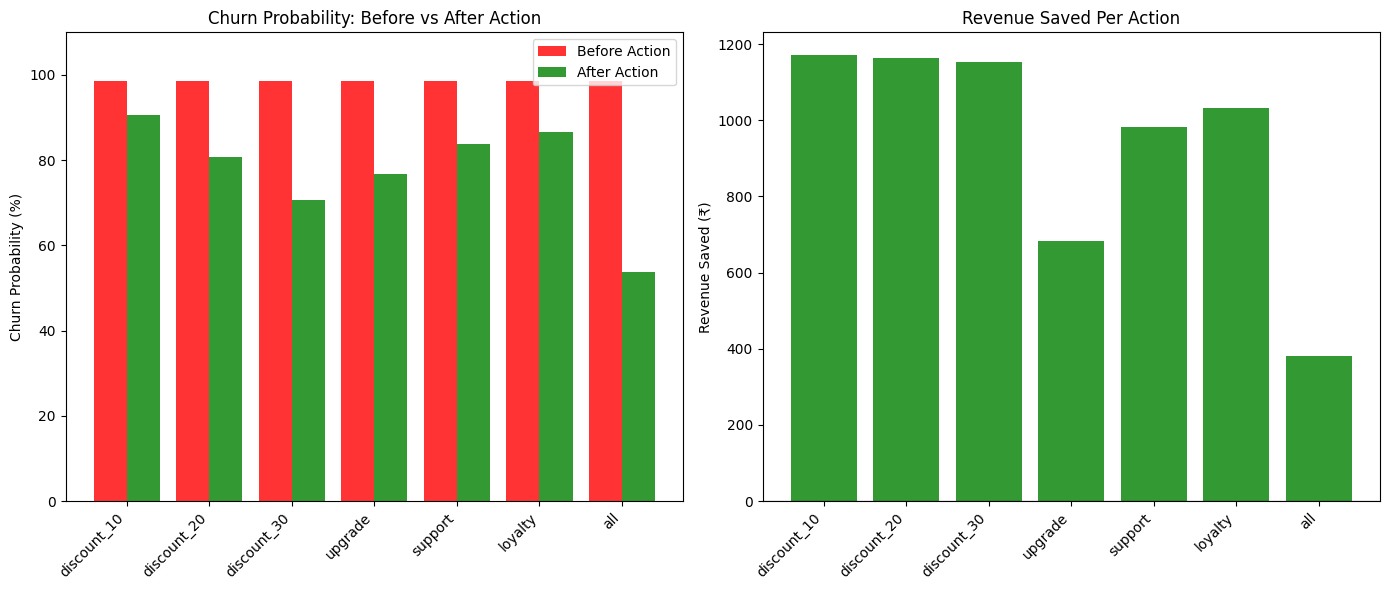

✅ What-If chart saved!


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1 — Churn probability before vs after
x = range(len(results_df))
axes[0].bar([i-0.2 for i in x], results_df['Before'],
            0.4, label='Before Action', color='red', alpha=0.8)
axes[0].bar([i+0.2 for i in x], results_df['After'],
            0.4, label='After Action', color='green', alpha=0.8)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(results_df['Action'], rotation=45, ha='right')
axes[0].set_ylabel('Churn Probability (%)')
axes[0].set_title('Churn Probability: Before vs After Action')
axes[0].legend()
axes[0].set_ylim(0, 110)

# Chart 2 — Revenue saved per action
colors = ['green' if x > 0 else 'red' for x in results_df['Revenue_Saved']]
axes[1].bar(results_df['Action'], results_df['Revenue_Saved'],
            color=colors, alpha=0.8)
axes[1].set_xticklabels(results_df['Action'], rotation=45, ha='right')
axes[1].set_ylabel('Revenue Saved (₹)')
axes[1].set_title('Revenue Saved Per Action')
axes[1].axhline(y=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig(os.path.join(BASE, "docs", "whatif_results.png"), dpi=150)
plt.show()
print("✅ What-If chart saved!")

In [6]:
def revenue_at_risk_calculator(df, monthly_col='MonthlyCharges'):
    """
    Calculate total revenue at risk from
    high risk customers
    """
    print("💰 REVENUE AT RISK CALCULATOR")
    print("="*55)
    
    # Categorize customers
    critical = df[df['churn_prob_30day'] >= 75]
    high     = df[(df['churn_prob_30day'] >= 50) & 
                  (df['churn_prob_30day'] < 75)]
    medium   = df[(df['churn_prob_30day'] >= 25) & 
                  (df['churn_prob_30day'] < 50)]
    low      = df[df['churn_prob_30day'] < 25]
    
    # Calculate revenue at risk
    if monthly_col in df.columns:
        crit_rev   = critical[monthly_col].sum() * 12
        high_rev   = high[monthly_col].sum() * 12
        med_rev    = medium[monthly_col].sum() * 12
        total_risk = crit_rev + high_rev
    else:
        avg_monthly = 65
        crit_rev   = len(critical) * avg_monthly * 12
        high_rev   = len(high) * avg_monthly * 12
        med_rev    = len(medium) * avg_monthly * 12
        total_risk = crit_rev + high_rev
    
    print(f"\n🔴 CRITICAL Risk Customers : {len(critical):,}")
    print(f"   Revenue at Risk         : ₹{crit_rev:,.0f}/year")
    print(f"\n🟠 HIGH Risk Customers     : {len(high):,}")
    print(f"   Revenue at Risk         : ₹{high_rev:,.0f}/year")
    print(f"\n🟡 MEDIUM Risk Customers   : {len(medium):,}")
    print(f"   Revenue at Risk         : ₹{med_rev:,.0f}/year")
    print(f"\n🟢 LOW Risk Customers      : {len(low):,}")
    print(f"\n{'='*55}")
    print(f"⚠️  TOTAL REVENUE AT RISK   : ₹{total_risk:,.0f}/year")
    print(f"{'='*55}")
    
    # What if we retain 50% of high risk customers
    saved_50 = total_risk * 0.50
    print(f"\n💡 If we retain 50% of high risk customers:")
    print(f"   Revenue Saved = ₹{saved_50:,.0f}/year")
    
    # What if we retain 80%
    saved_80 = total_risk * 0.80
    print(f"\n💡 If we retain 80% of high risk customers:")
    print(f"   Revenue Saved = ₹{saved_80:,.0f}/year")
    
    return {
        'critical_count': len(critical),
        'high_count': len(high),
        'medium_count': len(medium),
        'low_count': len(low),
        'total_risk': total_risk,
        'saved_50pct': saved_50,
        'saved_80pct': saved_80
    }

revenue_stats = revenue_at_risk_calculator(telco)

💰 REVENUE AT RISK CALCULATOR

🔴 CRITICAL Risk Customers : 952
   Revenue at Risk         : ₹916,430/year

🟠 HIGH Risk Customers     : 1,007
   Revenue at Risk         : ₹857,942/year

🟡 MEDIUM Risk Customers   : 962
   Revenue at Risk         : ₹799,672/year

🟢 LOW Risk Customers      : 4,122

⚠️  TOTAL REVENUE AT RISK   : ₹1,774,373/year

💡 If we retain 50% of high risk customers:
   Revenue Saved = ₹887,186/year

💡 If we retain 80% of high risk customers:
   Revenue Saved = ₹1,419,498/year


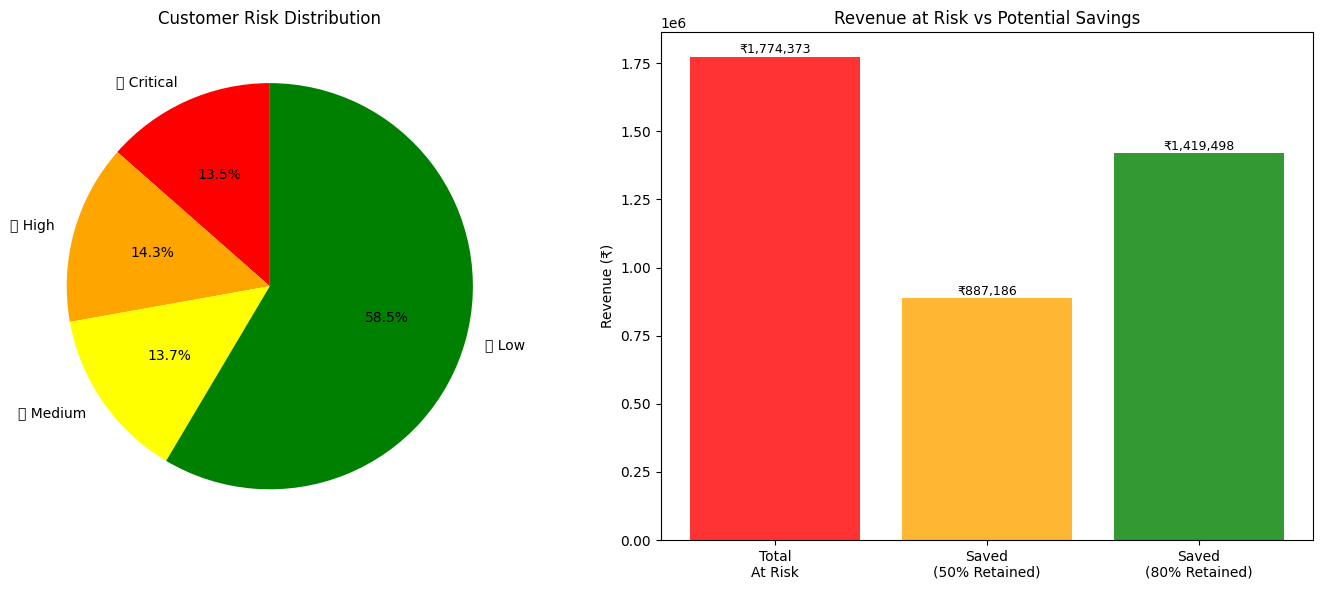

✅ Revenue at Risk chart saved!


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1 — Customer count by risk
labels = ['🔴 Critical', '🟠 High', '🟡 Medium', '🟢 Low']
counts = [
    revenue_stats['critical_count'],
    revenue_stats['high_count'],
    revenue_stats['medium_count'],
    revenue_stats['low_count']
]
colors = ['red', 'orange', 'yellow', 'green']

axes[0].pie(counts, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90)
axes[0].set_title('Customer Risk Distribution')

# Chart 2 — Revenue scenarios
scenarios = ['Total\nAt Risk', 'Saved\n(50% Retained)', 'Saved\n(80% Retained)']
amounts = [
    revenue_stats['total_risk'],
    revenue_stats['saved_50pct'],
    revenue_stats['saved_80pct']
]
bar_colors = ['red', 'orange', 'green']

bars = axes[1].bar(scenarios, amounts, color=bar_colors, alpha=0.8)
axes[1].set_ylabel('Revenue (₹)')
axes[1].set_title('Revenue at Risk vs Potential Savings')

# Add value labels on bars
for bar, amount in zip(bars, amounts):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1000,
        f'₹{amount:,.0f}',
        ha='center', va='bottom', fontsize=9
    )

plt.tight_layout()
plt.savefig(os.path.join(BASE, "docs", "revenue_at_risk.png"), dpi=150)
plt.show()
print("✅ Revenue at Risk chart saved!")